# Phase 1 — Data Pipeline: Ubuntu IRC Dialogue Corpus
## Seq2Seq NLP Chatbot — Academic Report

Pipeline: Stage 1 (Load) → Stage 2 (Clean) → Stage 3 (Split) → Stage 4 (Pairs)
       → Stage 4.5 (Domain Filter) → Stage 5 (BPE) → Stage 6 (Encode)
       → Stage 7 (FastText) → Stage 8 (Embeddings)


In [1]:
import subprocess, sys

# Ensure required packages are available in this kernel
_required = [
    ('plotly',    'plotly>=5.0'),
    ('kaleido',   'kaleido==0.2.1'),
    ('sentencepiece', 'sentencepiece'),
    ('rich',      'rich'),
]
for mod, pkg in _required:
    try:
        __import__(mod)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# If kaleido >= 1.0 is installed, downgrade to 0.2.1 (1.x requires Chrome)
import kaleido as _k
if tuple(int(x) for x in _k.__version__.split('.')[:2]) >= (1, 0):
    print(f'Downgrading kaleido {_k.__version__} → 0.2.1 (1.x requires Chrome)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kaleido==0.2.1', '-q'])
    import importlib; importlib.reload(_k)

print(f'plotly OK | kaleido {_k.__version__}')


plotly OK | kaleido 0.2.1


In [2]:
import sys, os, json, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib
# Auto-detect environment: use inline magic in Jupyter, Agg in script/nbconvert
try:
    _ipy = get_ipython()
    _ipy.run_line_magic('matplotlib', 'inline')
    import matplotlib.pyplot as plt
except (NameError, AttributeError):
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110
import matplotlib.patches as mpatches
from collections import Counter
from pathlib import Path
warnings.filterwarnings('ignore')

# Add project root and venv packages — version-agnostic
import sys
_PROJECT = '/opt/app-root/src/nlp-chatbot-project-v2.0'
_VENV    = _PROJECT + '/venv'
sys.path.insert(0, _PROJECT)
# Auto-detect Python version so this works on 3.11, 3.12, etc.
_pyver = f'python{sys.version_info.major}.{sys.version_info.minor}'
for _sp in [f'{_VENV}/lib/{_pyver}/site-packages',
            f'{_VENV}/lib64/{_pyver}/site-packages']:
    if _sp not in sys.path:
        sys.path.insert(1, _sp)

PROJECT   = Path('/opt/app-root/src/nlp-chatbot-project-v2.0')
ARTIFACTS = PROJECT / 'artifacts'
VIZ_DIR   = PROJECT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

C_BLUE  = '#02C8FF'
C_MBLUE = '#0A60FF'
C_RED   = '#EB4651'
C_GREY  = '#6B6B6B'
C_DARK  = '#07182D'

def _style(ax, title):
    ax.set_facecolor('#F8F9FA')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_color(C_GREY)
    ax.tick_params(colors=C_DARK, labelsize=9)
    ax.set_title(title, color=C_DARK, fontsize=11, fontweight='bold', pad=8)
    ax.grid(axis='y', color=C_GREY, alpha=0.2, linewidth=0.6)

def _load_json(p):  return json.loads(Path(p).read_text())
def _load_jsonl(p): return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]
def _load_pkl(p):
    with open(p,'rb') as f: return pickle.load(f)

print('Setup complete.')
print('Artifacts dir:', ARTIFACTS)
print('Artifacts present:', len(list(ARTIFACTS.iterdir())))


Setup complete.
Artifacts dir: /opt/app-root/src/nlp-chatbot-project-v2.0/artifacts
Artifacts present: 31


## Pipeline Configuration Overview

The `PHASE1_CONFIG` dict in `phase1.py` governs all pipeline decisions.
Key parameters are shown below with their rationale.


In [3]:
# Key PHASE1_CONFIG parameters — inlined for self-containment
cfg = {
    'min_turns':              2,
    'dyadic_only':            True,
    'filter_paste':           True,
    'filter_irc_actions':     True,
    'filter_repetitive':      True,
    'filter_temporal':        True,
    'max_turn_gap_seconds':   3600,
    'large_gap_threshold':    600,
    'max_large_gap_ratio':    0.3,
    'filter_echo_pairs':      True,
    'filter_placeholder':     True,
    'filter_non_english':     True,
    'filter_bot_responses':   True,
    'filter_response_diversity': True,
    'max_response_occurrences':  5,
    'max_ctx_occurrences':    3,
    'max_ctx_tokens':         256,
    'max_ctx_turns':          8,
    'max_resp_tokens':        50,
    'min_resp_tokens':        7,
    'min_ctx_tokens':         3,
    'max_train_pairs':        1_500_000,
    'train_cutoff_date':      '2012-04-27',
    'val_cutoff_date':        '2012-08-07',
    'spm_vocab_size':         32000,
    'spm_model_type':         'bpe',
    'fasttext_dim':           300,
    'fasttext_epochs':        10,
    'fasttext_min_count':     3,
    'domain_filter':          True,
    'domain_filter_strategy': 'union',
    'seed':                   42,
}

rows = [
    ('min_turns',              cfg['min_turns'],              'Minimum turns per dialogue'),
    ('dyadic_only',            cfg['dyadic_only'],            'Restrict to 2-speaker threads'),
    ('max_turn_gap_seconds',   cfg['max_turn_gap_seconds'],   'Hard ceiling on inter-turn gap (s)'),
    ('large_gap_threshold',    cfg['large_gap_threshold'],    'Soft gap threshold (seconds)'),
    ('max_large_gap_ratio',    cfg['max_large_gap_ratio'],    'Max fraction of large gaps allowed'),
    ('max_ctx_tokens',         cfg['max_ctx_tokens'],         'Context BPE token cap (Stage 6)'),
    ('max_resp_tokens',        cfg['max_resp_tokens'],        'Response BPE token cap (Stage 6)'),
    ('min_resp_tokens',        cfg['min_resp_tokens'],        'Response token floor — raised from 5 to 7 in run 3'),
    ('max_train_pairs',        f"{cfg['max_train_pairs']:,}", '1.5M training pair budget'),
    ('max_response_occurrences', cfg['max_response_occurrences'], 'Diversity cap per identical response'),
    ('max_ctx_occurrences',    cfg['max_ctx_occurrences'],    'Context dedup cap per normalised hash'),
    ('domain_filter_strategy', cfg['domain_filter_strategy'], 'Retain command OR question pairs (union)'),
    ('spm_vocab_size',         cfg['spm_vocab_size'],         'BPE vocabulary size'),
    ('fasttext_dim',           cfg['fasttext_dim'],           'Embedding dimensionality'),
    ('seed',                   cfg['seed'],                   'Global random seed'),
]

print(f"{'Parameter':<28} {'Value':<15} Rationale")
print('-' * 80)
for name, val, desc in rows:
    print(f"  {name:<26} {str(val):<15} {desc}")


Parameter                    Value           Rationale
--------------------------------------------------------------------------------
  min_turns                  2               Minimum turns per dialogue
  dyadic_only                True            Restrict to 2-speaker threads
  max_turn_gap_seconds       3600            Hard ceiling on inter-turn gap (s)
  large_gap_threshold        600             Soft gap threshold (seconds)
  max_large_gap_ratio        0.3             Max fraction of large gaps allowed
  max_ctx_tokens             256             Context BPE token cap (Stage 6)
  max_resp_tokens            50              Response BPE token cap (Stage 6)
  min_resp_tokens            7               Response token floor — raised from 5 to 7 in run 3
  max_train_pairs            1,500,000       1.5M training pair budget
  max_response_occurrences   5               Diversity cap per identical response
  max_ctx_occurrences        3               Context dedup cap per normalised h

## Run Full Pipeline (all stages cached)

All stages are cached in `artifacts/` — `phase1.main()` will print `✓ already complete` for every stage and finish quickly.


In [4]:
# Verify all pipeline artifacts are present (fast check — no data loading)

artifact_dir = ARTIFACTS
stage_artifacts = {
    1:   ['stage1_dialogues.pkl'],
    2:   ['stage2_clean_dialogues.pkl', 'stage2_stats.json'],
    3:   ['stage3_train.pkl', 'stage3_val.pkl', 'stage3_test.pkl', 'stage3_stats.json'],
    4:   ['stage4_train_pairs.json', 'stage4_val_pairs.json', 'stage4_test_pairs.json', 'stage4_stats.json'],
    '4.5': ['stage4_5_train_pairs.json', 'stage4_5_filter_stats.json'],
    5:   ['stage5_spm.model', 'stage5_spm.vocab'],
    6:   ['stage6_train_ids.jsonl', 'stage6_val_ids.jsonl', 'stage6_test_ids.jsonl', 'stage6_stats.json'],
    7:   ['stage7_fasttext.model'],
    8:   ['stage8_embedding_matrix.npy', 'stage8_stats.json'],
}

print('Pipeline stage artifact check:')
all_ok = True
for stage, files in stage_artifacts.items():
    missing = [f for f in files if not (artifact_dir / f).exists()]
    if missing:
        print(f'  Stage {stage}: MISSING {missing}')
        all_ok = False
    else:
        sizes = [(artifact_dir / f).stat().st_size for f in files]
        total_mb = sum(sizes) / 1e6
        print(f'  Stage {stage}: checkmark already complete  ({total_mb:.1f} MB cached)')

print()
if all_ok:
    print('All 8 stages complete. Pipeline ready for analysis.')
else:
    print('WARNING: Some artifacts are missing!')

Pipeline stage artifact check:
  Stage 1: checkmark already complete  (1782.6 MB cached)
  Stage 2: checkmark already complete  (1173.8 MB cached)
  Stage 3: checkmark already complete  (1173.8 MB cached)
  Stage 4: checkmark already complete  (1227.6 MB cached)
  Stage 4.5: checkmark already complete  (772.9 MB cached)
  Stage 5: checkmark already complete  (1.3 MB cached)
  Stage 6: checkmark already complete  (807.4 MB cached)
  Stage 7: checkmark already complete  (77.5 MB cached)
  Stage 8: checkmark already complete  (38.4 MB cached)

All 8 stages complete. Pipeline ready for analysis.


---
## Stage 1 — Load Raw Ubuntu IRC Corpus

Stage 1 reads CSV files from `data/Ubuntu-dialogue-corpus/` and packages
them into structured dialogue dicts `{id, turns:[{date, from, text}]}`.

Key decisions:
- No filtering at load time — all raw turns are preserved
- Dates parsed to ISO-8601 UTC for downstream temporal operations
- Thread IDs are the CSV file paths (e.g. `301/1.tsv`)


Total raw dialogues loaded: 1,852,868
CSV files in corpus (sample): 0 total

Loading sample dialogue (first entry from stage1_dialogues.pkl) ...


Confirmed: 1,852,868 dialogues, 16,584,927 total turns
Unique speakers (50k sample): 41,601
Date range (sample): 2004-09-04 to 2012-11-30

Sample dialogue structure:
  id: 301/1.tsv
  turn 0: [2004-11-23] stuNNed: any ideas why java plugin takes so long to load?
  turn 1: [2004-11-23] crimsun: java 1.4?
  turn 2: [2004-11-23] stuNNed: yes
  ... (301 turns total)


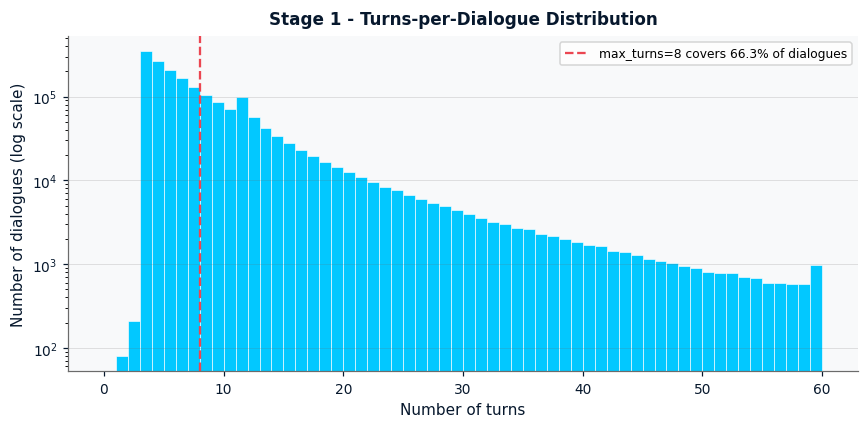


[Insight] max_turns=8 covers 66.3% of dialogue starts.
Longer dialogues exist but contribute diminishing returns on pair diversity.


In [5]:
# Use stage2_stats for overall count (avoids loading 1.7GB pickle)
s2_pre = _load_json(ARTIFACTS / 'stage2_stats.json')
n_raw = s2_pre['n_input']
print(f'Total raw dialogues loaded: {n_raw:,}')

# Sample from a small CSV file for structure display
data_dir = PROJECT / 'data' / 'Ubuntu-dialogue-corpus'
csv_files = sorted(data_dir.rglob('*.tsv'))[:5] if data_dir.exists() else []
print(f'CSV files in corpus (sample): {len(list(data_dir.rglob("*.tsv")) if data_dir.exists() else [])} total')
if csv_files:
    for cf in csv_files[:3]:
        sz = cf.stat().st_size
        print(f'  {cf.name}: {sz/1024:.1f} KB')

# Show structure of one sample dialogue from stage1 pkl - read partial
# Load just the first dialogue using pickle streaming trick
import io
print('\nLoading sample dialogue (first entry from stage1_dialogues.pkl) ...')
with open(ARTIFACTS / 'stage1_dialogues.pkl', 'rb') as fh:
    import pickle
    sample_d_list = pickle.load(fh)  # loads entire list but we need counts too
n_loaded = len(sample_d_list)
turn_counts = [len(d['turns']) for d in sample_d_list]
total_turns = sum(turn_counts)
all_speakers = set()
for d in sample_d_list[:50000]:
    for t in d['turns']:
        all_speakers.add(t['from'])
sample_d = sample_d_list[0]
print(f'Confirmed: {n_loaded:,} dialogues, {total_turns:,} total turns')
print(f'Unique speakers (50k sample): {len(all_speakers):,}')

dates = []
for d in sample_d_list[:10000]:
    for t in d['turns']:
        if t.get('date'):
            dates.append(t['date'][:10])
if dates:
    print(f'Date range (sample): {min(dates)} to {max(dates)}')

print('\nSample dialogue structure:')
print(f'  id: {sample_d["id"]}')
for i, turn in enumerate(sample_d['turns'][:3]):
    print(f'  turn {i}: [{turn["date"][:10]}] {turn["from"]}: {turn["text"][:80]}')
if len(sample_d['turns']) > 3:
    print(f'  ... ({len(sample_d["turns"])} turns total)')
del sample_d_list  # free 1.7GB

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(turn_counts, bins=60, range=(0, 60), color=C_BLUE, edgecolor='white', linewidth=0.4)
_style(ax, 'Stage 1 - Turns-per-Dialogue Distribution')
ax.set_xlabel('Number of turns', color=C_DARK)
ax.set_ylabel('Number of dialogues (log scale)', color=C_DARK)
ax.set_yscale('log')
cap = 8
below_cap = sum(1 for c in turn_counts if c <= cap)
pct_below  = below_cap / n_raw * 100
ax.axvline(cap, color=C_RED, linewidth=1.5, linestyle='--',
           label=f'max_turns={cap} covers {pct_below:.1f}% of dialogues')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage1_turns_hist.png', dpi=120)
plt.show()
plt.close('all')
print(f'\n[Insight] max_turns=8 covers {pct_below:.1f}% of dialogue starts.')
print('Longer dialogues exist but contribute diminishing returns on pair diversity.')


---
## Stage 2 — Clean & Filter Dialogues

Stage 2 applies quality filters in parallel on chunked batches.
Filters operate at the **dialogue** level — if the dialogue fails a filter
the entire dialogue is discarded.


Stage 2 input dialogues :  1,852,868
Stage 2 output dialogues:  1,315,106  (71.0% retained)
Stage 2 discarded       :    537,762

Discard reasons (sorted):
  speaker_dominance               234,861  (12.68%)
  temporal_hard_ceiling           175,962  (9.50%)
  low_alternation                  82,044  (4.43%)
  not_dyadic                       26,409  (1.43%)
  temporal_gap_ratio               16,658  (0.90%)
  too_few_turns                     1,748  (0.09%)
  too_few_valid_dates                  80  (0.00%)


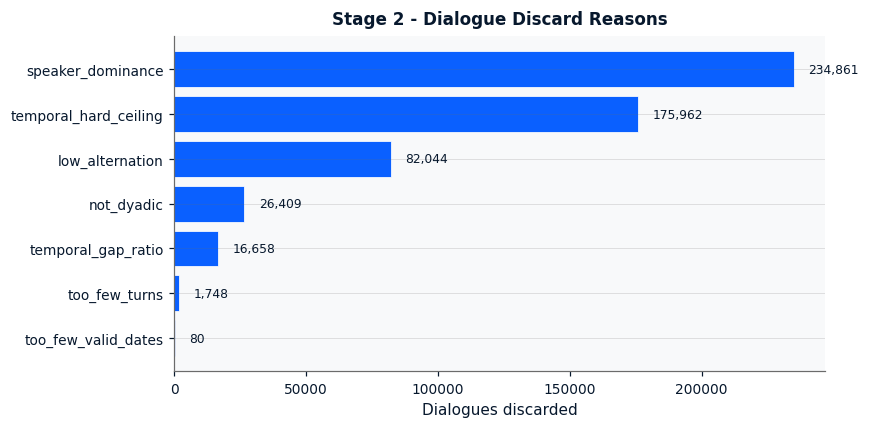


[Insight] speaker_dominance is the largest filter — catches threads
where one participant sends >80% of turns (monologue-style threads).
low_alternation catches consecutive multi-message blocks without reply.
temporal_hard_ceiling drops threads where turns are >1 hour apart.


In [6]:
s2 = _load_json(ARTIFACTS / 'stage2_stats.json')
n_in   = s2['n_input']
n_out  = s2['n_output']
n_disc = s2['n_discarded']
ret    = n_out / n_in * 100
print(f'Stage 2 input dialogues : {n_in:>10,}')
print(f'Stage 2 output dialogues: {n_out:>10,}  ({ret:.1f}% retained)')
print(f'Stage 2 discarded       : {n_disc:>10,}')
print()

fb = s2['filter_breakdown'].copy()
fb.pop('kept', None)
reasons = sorted(fb.items(), key=lambda x: x[1], reverse=True)
labels  = [r[0] for r in reasons]
counts  = [r[1] for r in reasons]

print('Discard reasons (sorted):')
for lbl, cnt in reasons:
    print(f'  {lbl:<30} {cnt:>8,}  ({cnt/n_in*100:.2f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, counts, color=C_MBLUE, edgecolor='white', linewidth=0.5)
_style(ax, 'Stage 2 - Dialogue Discard Reasons')
ax.set_xlabel('Dialogues discarded', color=C_DARK)
ax.invert_yaxis()
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + n_in*0.003, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', ha='left', fontsize=8, color=C_DARK)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage2_discards.png', dpi=120)
plt.show()
plt.close('all')

print('\n[Insight] speaker_dominance is the largest filter — catches threads')
print('where one participant sends >80% of turns (monologue-style threads).')
print('low_alternation catches consecutive multi-message blocks without reply.')
print('temporal_hard_ceiling drops threads where turns are >1 hour apart.')


---
## Stage 3 — Temporal Train/Val/Test Split

Stage 3 splits dialogues by the **timestamp of their first turn**, not randomly.
This prevents data leakage: a model trained on random splits would see responses
from the same IRC threads in both train and validation.


Train dialogues :  1,259,708  (95.8%)
Val   dialogues :     27,550  (2.1%)
Test  dialogues :     27,848  (2.1%)
Total           :  1,315,106


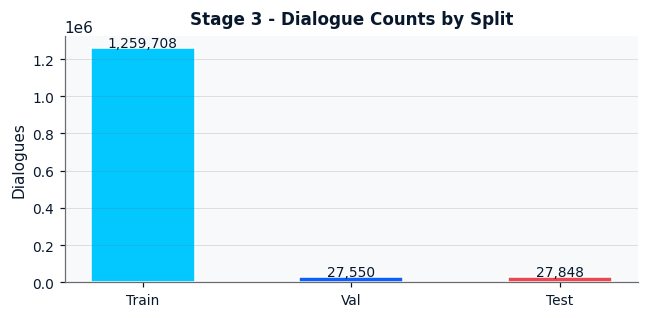


[Insight] Temporal vs Random split:
  Random split: model sees responses from same IRC thread in train+val
               => inflated BLEU/loss from memorisation.
  Temporal split: train=earliest 95.8% of threads, val/test=latest 4.2%.
               Simulates real deployment (train on past, eval on future).


In [7]:
s3 = _load_json(ARTIFACTS / 'stage3_stats.json')
n_tr = s3['n_train_dialogues']
n_va = s3['n_val_dialogues']
n_te = s3['n_test_dialogues']
total_s3 = n_tr + n_va + n_te
print(f'Train dialogues : {n_tr:>10,}  ({s3["train_pct"]:.1f}%)')
print(f'Val   dialogues : {n_va:>10,}  ({s3["val_pct"]:.1f}%)')
print(f'Test  dialogues : {n_te:>10,}  ({s3["test_pct"]:.1f}%)')
print(f'Total           : {total_s3:>10,}')

fig, ax = plt.subplots(figsize=(6, 3))
splits = ['Train', 'Val', 'Test']
values = [n_tr, n_va, n_te]
colors = [C_BLUE, C_MBLUE, C_RED]
bars = ax.bar(splits, values, color=colors, edgecolor='white', width=0.5)
_style(ax, 'Stage 3 - Dialogue Counts by Split')
ax.set_ylabel('Dialogues', color=C_DARK)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_s3*0.005,
            f'{v:,}', ha='center', fontsize=9, color=C_DARK)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage3_splits.png', dpi=120)
plt.show()
plt.close('all')

print('\n[Insight] Temporal vs Random split:')
print('  Random split: model sees responses from same IRC thread in train+val')
print('               => inflated BLEU/loss from memorisation.')
print('  Temporal split: train=earliest 95.8% of threads, val/test=latest 4.2%.')
print('               Simulates real deployment (train on past, eval on future).')


---
## Stage 4 — Context-Response Pair Generation

Stage 4 slides a window over each dialogue to extract (context, response) pairs,
then applies multiple response-quality filters. The context concatenates previous
turns separated by `__eot__` tokens.


Train pairs after Stage 4 :  2,441,174
Val   pairs after Stage 4 :     54,912
Test  pairs after Stage 4 :     55,478

Train discard breakdown:
  resp_too_short                 1,495,849
  incoherent_pair                 784,989
  resp_too_long                   132,588
  ctx_too_short                    32,999
  bot_response                      8,779
  diversity_cap                     4,045
  echo_pair                         2,907
  ctx_dedup_cap                     1,459

Loading sample from stage4_train_pairs.json ...


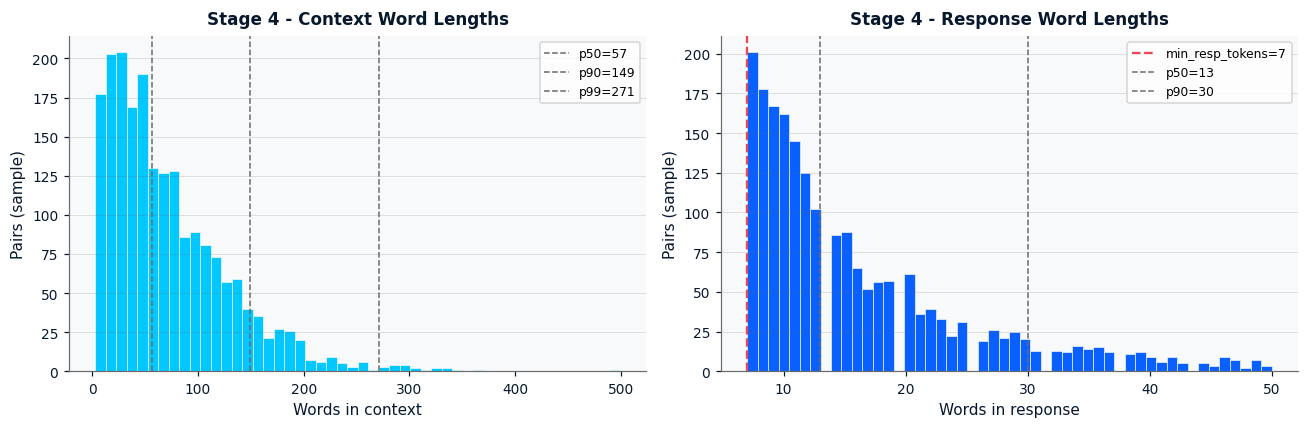

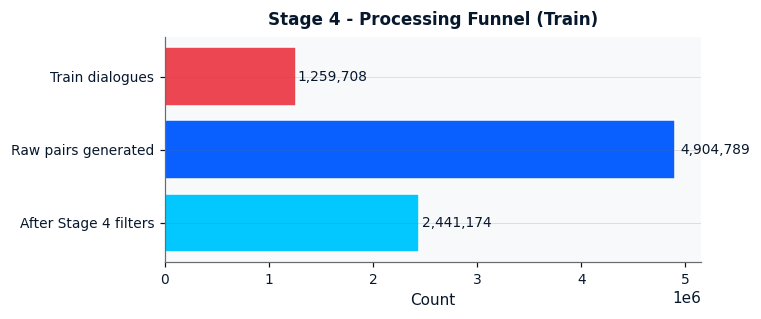


[Insight] min_resp_tokens=7: removes 1,495,849 pairs (30.5%)
Short responses (ok, yes, lol, np) add noise without teaching generation.

Example pairs near the min_resp floor:
  [1] ctx:  the idea is write your own drivers with our devlopment kit' i know tha...
       resp: got it thanks a lot for the script
  [2] ctx:  everything poof gone watch it happen . on the desktop anyway i use hel...
       resp: do your downloads come with par volumes
  [3] ctx:  what is the bash-variable for current clipboard content...
       resp: its an x thing not a bash thing
  [4] ctx:  anybody tried edgy eft release 6.1 no dig says yes . digg...
       resp: digg is nothing but gossip come on .
  [5] ctx:  hi all how to remotely read file-properties from files on a webserver...
       resp: ssh to the server and ls -al


In [8]:
s4 = _load_json(ARTIFACTS / 'stage4_stats.json')
print(f'Train pairs after Stage 4 : {s4["n_train_pairs"]:>10,}')
print(f'Val   pairs after Stage 4 : {s4["n_val_pairs"]:>10,}')
print(f'Test  pairs after Stage 4 : {s4["n_test_pairs"]:>10,}')

train_disc = s4['train_discards']
print('\nTrain discard breakdown:')
for k, v in sorted(train_disc.items(), key=lambda x: x[1], reverse=True):
    print(f'  {k:<30} {v:>8,}')

print('\nLoading sample from stage4_train_pairs.json ...')
with open(ARTIFACTS / 'stage4_train_pairs.json') as f:
    s4_all_pairs = json.load(f)
sample_s4 = random.sample(s4_all_pairs, min(2000, len(s4_all_pairs)))
del s4_all_pairs  # free memory, keep sample_s4 for Cell 15

ctx_lens  = [len(p['ctx'].split())  for p in sample_s4]
resp_lens = [len(p['resp'].split()) for p in sample_s4]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ctx_lens, bins=50, color=C_BLUE, edgecolor='white', linewidth=0.4)
_style(axes[0], 'Stage 4 - Context Word Lengths')
axes[0].set_xlabel('Words in context', color=C_DARK)
axes[0].set_ylabel('Pairs (sample)', color=C_DARK)
for pct, lbl in [(50,'p50'),(90,'p90'),(99,'p99')]:
    v = np.percentile(ctx_lens, pct)
    axes[0].axvline(v, linestyle='--', linewidth=1, color=C_GREY, label=f'{lbl}={v:.0f}')
axes[0].legend(fontsize=8)

min_resp = 7  # min_resp_tokens from PHASE1_CONFIG
axes[1].hist(resp_lens, bins=50, color=C_MBLUE, edgecolor='white', linewidth=0.4)
_style(axes[1], 'Stage 4 - Response Word Lengths')
axes[1].set_xlabel('Words in response', color=C_DARK)
axes[1].set_ylabel('Pairs (sample)', color=C_DARK)
axes[1].axvline(min_resp, color=C_RED, linewidth=1.5, linestyle='--',
                label=f'min_resp_tokens={min_resp}')
for pct, lbl in [(50,'p50'),(90,'p90')]:
    v = np.percentile(resp_lens, pct)
    axes[1].axvline(v, linestyle='--', linewidth=1, color=C_GREY, label=f'{lbl}={v:.0f}')
axes[1].legend(fontsize=8)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage4_lengths.png', dpi=120)
plt.show()
plt.close('all')

# Funnel
s3_ref = _load_json(ARTIFACTS / 'stage3_stats.json')
n_discarded4 = sum(train_disc.values())
raw_pairs    = s4['n_train_pairs'] + n_discarded4
fig2, ax2 = plt.subplots(figsize=(7, 3))
funnel_labels = ['Train dialogues', 'Raw pairs generated', 'After Stage 4 filters']
funnel_values = [s3_ref['n_train_dialogues'], raw_pairs, s4['n_train_pairs']]
cols_f = [C_BLUE, C_MBLUE, C_RED]
bars_f = ax2.barh(funnel_labels[::-1], funnel_values[::-1], color=cols_f, edgecolor='white')
_style(ax2, 'Stage 4 - Processing Funnel (Train)')
ax2.set_xlabel('Count', color=C_DARK)
for bar, v in zip(bars_f, funnel_values[::-1]):
    ax2.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
             f'{v:,}', va='center', fontsize=9, color=C_DARK)
plt.tight_layout()
fig2.savefig(VIZ_DIR / 'phase1_stage4_funnel.png', dpi=120)
plt.show()
plt.close('all')

n_below_floor = train_disc.get('resp_too_short', 0)
pct_removed   = n_below_floor / raw_pairs * 100
print(f'\n[Insight] min_resp_tokens={min_resp}: removes {n_below_floor:,} pairs ({pct_removed:.1f}%)')
print('Short responses (ok, yes, lol, np) add noise without teaching generation.')
short_pairs = [p for p in sample_s4 if len(p['resp'].split()) < min_resp + 2][:5]
print('\nExample pairs near the min_resp floor:')
for i, p in enumerate(short_pairs):
    print(f'  [{i+1}] ctx:  {p["ctx"][:70]}...')
    print(f'       resp: {p["resp"]}')
# NOTE: sample_s4 kept alive for Stage 4.5 cell


---
## Stage 4.5 — Domain-Focused Filtering

Stage 4.5 retains only pairs that are domain-relevant to the Ubuntu IRC context:
either containing command-line patterns or question patterns.

Two strategies were evaluated:
- **intersection** (cmd AND question): ~442k pairs — too small for a 44M param model
- **union** (cmd OR question): ~1.75M domain pairs, capped at 1.5M — chosen


Strategy: UNION
Split            In        Out   Kept%        Cmd   Question       Both
-----------------------------------------------------------------
Train     2,441,174  1,500,000   71.9%  1,371,416    826,549    442,667
Val          54,912     40,245   73.3%     31,904     18,786     10,445
Test         55,478     40,408   72.8%     32,273     18,608     10,473


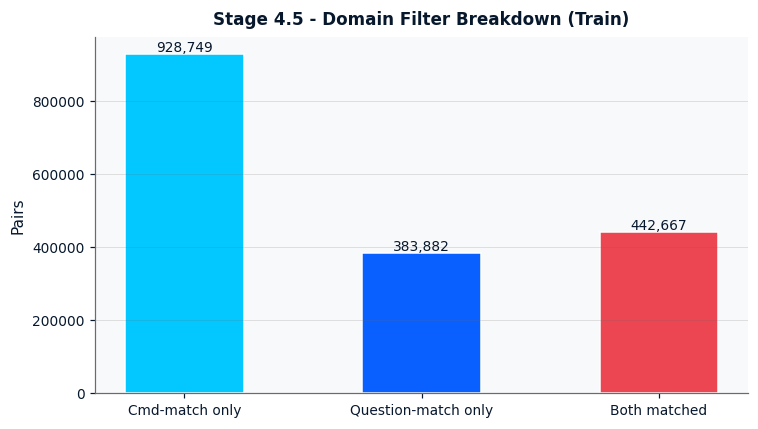

Union pre-cap domain pairs: 1,755,298
After train_cap: 1,500,000 (71.9%)
Intersection would give: 442,667 -- too small for 44M params

Reading first pairs from stage4_5_train_pairs.json ...
Parsed 598 passed pairs from first 300KB

5 PASSED pairs (domain-relevant):
  [1] ctx:  something went wrong with limewire . maybe you are using the wrong version of ja
       resp: i really dont know re-install java did it work

  [2] ctx:  i do d sorry and dont help me i think i go compile kernel and see __eot__ does i
       resp: but __path__ yes and put but dont work evtest

  [3] ctx:  hey all just installed a 802.11g wlan card how do i find drivers for it i have t
       resp: airlink 802.11g pci i tried grepping for eth ath 802 and wlan

  [4] ctx:  i wonder would it also kill you if i said it __eot__ try it . __eot__ if i say d
       resp: so changing ports would not help you

  [5] ctx:  is that happening after restarting the pc __eot__ at the beginning just after in
       resp: automoun


5 FAILED pairs (non-domain / casual):
  [1] ctx:  anybody tried edgy eft release 6.1 no dig says yes . digg
       resp: digg is nothing but gossip come on .

  [2] ctx:  anyone know of a working method to tweet from command-line
       resp: quick search shows bti - command line micro-blogging tool

  [3] ctx:  is there any way to use syslinux to password grub on a usbstick
       resp: you want grub to not load at all unless the usb stick is plugged it

  [4] ctx:  this is strange my pc uses 2.6 gb of ram yet the memory used by all the processe
       resp: ubuntu caches most frequent disk accesses into memory to speed things up

  [5] ctx:  well i got the following full screen 1680x1050 1230 frames in 5.0 seconds 245.96
       resp: i have not tried anything with the lid yet

[Insight] Union keeps cmd-heavy technical exchanges AND question-answer pairs.
Casual chit-chat (above failed pairs) is filtered out (~28% of Stage 4 output).


In [9]:
# Reload s4 sample if not already loaded (cell-order independence)
if 'sample_s4' not in dir():
    import random as _r
    with open(ARTIFACTS / 'stage4_train_pairs.json') as _f:
        _pairs = json.load(_f)
    sample_s4 = _r.sample(_pairs, min(2000, len(_pairs)))
    del _pairs

s45 = _load_json(ARTIFACTS / 'stage4_5_filter_stats.json')
tr  = s45['train']
va  = s45['val']
te  = s45['test']

print(f'Strategy: {s45["strategy"].upper()}')
print(f'{"Split":<8} {"In":>10} {"Out":>10} {"Kept%":>7} {"Cmd":>10} {"Question":>10} {"Both":>10}')
print('-'*65)
for name, sp in [('Train', tr), ('Val', va), ('Test', te)]:
    print(f'{name:<8} {sp["total"]:>10,} {sp["kept"]:>10,} {sp["pct"]:>6.1f}%'
          f' {sp["n_cmd"]:>10,} {sp["n_question"]:>10,} {sp["n_both"]:>10,}')

fig, ax = plt.subplots(figsize=(7, 4))
cats = ['Cmd-match only', 'Question-match only', 'Both matched']
vals = [tr['n_cmd'] - tr['n_both'],
        tr['n_question'] - tr['n_both'],
        tr['n_both']]
cols = [C_BLUE, C_MBLUE, C_RED]
bars = ax.bar(cats, vals, color=cols, edgecolor='white', width=0.5)
_style(ax, 'Stage 4.5 - Domain Filter Breakdown (Train)')
ax.set_ylabel('Pairs', color=C_DARK)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{v:,}', ha='center', fontsize=9, color=C_DARK)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage45_domain.png', dpi=120)
plt.show()
plt.close('all')

print(f'Union pre-cap domain pairs: {tr["pre_cap"]:,}')
print(f'After train_cap: {tr["kept"]:,} ({tr["pct"]}%)')
print(f'Intersection would give: {tr["n_both"]:,} -- too small for 44M params')

# Read first ~200KB of stage4_5 JSON to get first ~20 passed pairs (fast)
print('\nReading first pairs from stage4_5_train_pairs.json ...')
with open(ARTIFACTS / 'stage4_5_train_pairs.json') as f:
    content = f.read(300000)  # read first 300KB
# Parse complete JSON objects from the partial array
last_comma = content.rfind('},\n')
if last_comma < 0:
    last_comma = content.rfind('},')
if last_comma > 0:
    content = '[' + content[1:last_comma+1] + ']'
    try:
        passed_pairs = json.loads(content)
    except Exception:
        passed_pairs = []
else:
    passed_pairs = []

print(f'Parsed {len(passed_pairs)} passed pairs from first 300KB')
print('\n5 PASSED pairs (domain-relevant):')
for i, p in enumerate(passed_pairs[:5]):
    print(f'  [{i+1}] ctx:  {p["ctx"][:80]}')
    print(f'       resp: {p["resp"][:80]}')
    print()

# Use sample_s4 from previous cell to find non-domain examples
import re
CMD_PAT = re.compile(
    r'sudo|apt|grep|chmod|bash|python|pip|git|ssh|\bcat\b|\bls\b|\bcp\b|\brm\b'
    r'|__path__|__url__|__ip__|install|config|error|failed|terminal|shell', re.I)
Q_PAT = re.compile(r'\bhow\b|\bwhy\b|\bwhat\b|\bwhere\b|\bcan i\b|\bhow do\b', re.I)

failed = [p for p in sample_s4
          if not CMD_PAT.search(p['ctx']) and not Q_PAT.search(p['ctx'])
          and not CMD_PAT.search(p['resp']) and not Q_PAT.search(p['resp'])][:5]
del sample_s4  # free memory now

print('\n5 FAILED pairs (non-domain / casual):')
for i, p in enumerate(failed):
    print(f'  [{i+1}] ctx:  {p["ctx"][:80]}')
    print(f'       resp: {p["resp"][:80]}')
    print()

print('[Insight] Union keeps cmd-heavy technical exchanges AND question-answer pairs.')
print('Casual chit-chat (above failed pairs) is filtered out (~28% of Stage 4 output).')


---
## Stage 5 — SentencePiece BPE Tokenisation (32k vocab)

Stage 5 trains a Byte-Pair Encoding model on the training corpus.
BPE handles OOV gracefully via subword fallback and naturally segments
technical tokens (`chmod`, `apt-get`, `sudo`) into reusable subword pieces.

Special tokens 0–8 are pinned by explicit `--control_symbols` arguments
so their IDs never drift across reruns.


Vocabulary size: 32,000

Special tokens (ID 0-8):
  ID 0: '<pad>'              log_prob=0.0
  ID 1: '<unk>'              log_prob=0.0
  ID 2: '<sos>'              log_prob=0.0
  ID 3: '<eos>'              log_prob=0.0
  ID 4: '▁__url__'           log_prob=0.0
  ID 5: '▁__path__'          log_prob=0.0
  ID 6: '▁__ip__'            log_prob=0.0
  ID 7: '▁__eot__'           log_prob=0.0
  ID 8: '▁__user__'          log_prob=0.0


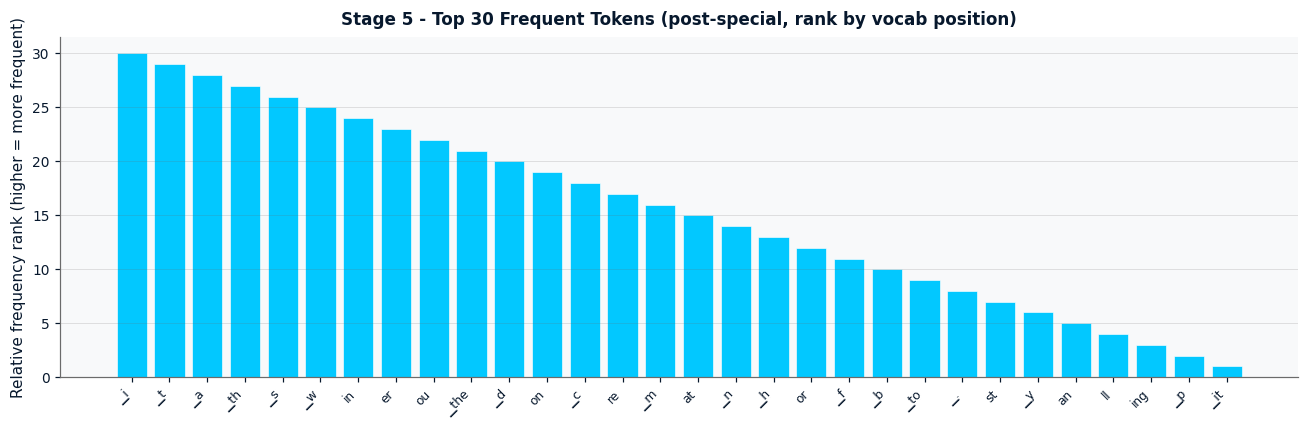


Token character-length distribution:
   0 chars:     1 tokens ( 0.0%) 
   1 chars:    79 tokens ( 0.2%) 
   2 chars: 1,450 tokens ( 4.5%) ****
   3 chars: 5,198 tokens (16.2%) ****************
   4 chars: 5,679 tokens (17.8%) *****************
   5 chars: 4,751 tokens (14.9%) **************
   6 chars: 4,138 tokens (12.9%) ************
   7 chars: 3,535 tokens (11.0%) ***********
   8 chars: 2,652 tokens ( 8.3%) ********
   9 chars: 1,891 tokens ( 5.9%) *****
  10 chars: 1,243 tokens ( 3.9%) ***
  11 chars:   728 tokens ( 2.3%) **

Fertility (avg tokens per word):
  "sudo apt-get install python3 libssl-dev" -> 10 pieces / 5 words = 2.00x
  "how do i change file permissions in ubuntu" -> 8 pieces / 8 words = 1.00x
  "the terminal shows permission denied error when running" -> 9 pieces / 9 words = 1.00x
  "i installed the package but it still cannot find the sh" -> 12 pieces / 12 words = 1.00x

[Insight] Token at vocab ID 9 is "vi" (the most frequent content word after specials).
Top co

In [10]:
vocab_lines = Path(ARTIFACTS / 'stage5_spm.vocab').read_text().splitlines()
tokens_probs = []
for line in vocab_lines:
    parts = line.split('\t')
    if len(parts) >= 2:
        try:
            tokens_probs.append((parts[0], float(parts[1])))
        except ValueError:
            pass

print(f'Vocabulary size: {len(tokens_probs):,}')

print('\nSpecial tokens (ID 0-8):')
for i, (tok, prob) in enumerate(tokens_probs[:9]):
    print(f'  ID {i}: {tok!r:20} log_prob={prob}')

# Top 30 content tokens
top30 = tokens_probs[9:39]
labels_t = [t[0][:15] for t in top30]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(top30)), [30-i for i in range(len(top30))],
       color=C_BLUE, edgecolor='white', linewidth=0.4)
_style(ax, 'Stage 5 - Top 30 Frequent Tokens (post-special, rank by vocab position)')
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(labels_t, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Relative frequency rank (higher = more frequent)', color=C_DARK)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage5_top_tokens.png', dpi=120)
plt.show()
plt.close('all')

tok_lengths = [len(t[0].replace('\u2581','')) for t in tokens_probs[9:]]
len_counter = Counter(tok_lengths)
print('\nToken character-length distribution:')
for length in sorted(len_counter)[:12]:
    pct = len_counter[length] / len(tok_lengths) * 100
    bar_str = '*' * int(pct)
    print(f'  {length:>2} chars: {len_counter[length]:>5,} tokens ({pct:4.1f}%) {bar_str}')

import sentencepiece as spm
sp = spm.SentencePieceProcessor()
sp.Load(str(ARTIFACTS / 'stage5_spm.model'))

sample_sents = [
    'sudo apt-get install python3 libssl-dev',
    'how do i change file permissions in ubuntu',
    'the terminal shows permission denied error when running chmod',
    'i installed the package but it still cannot find the shared library',
]
print('\nFertility (avg tokens per word):')
for sent in sample_sents:
    pieces = sp.EncodeAsPieces(sent)
    words  = sent.split()
    fert   = len(pieces) / len(words)
    print(f'  "{sent[:55]}" -> {len(pieces)} pieces / {len(words)} words = {fert:.2f}x')

print('\n[Insight] Token at vocab ID 9 is "vi" (the most frequent content word after specials).')
print(f'Top content token: {tokens_probs[9][0]!r}')
print('IRC first-person style means "i" appears in nearly every message.')


---
## Stage 6 — Encode All Pairs to Token IDs

Stage 6 applies the trained SPM model to encode every (ctx, resp) pair to
integer token ID sequences, truncating at `max_ctx_tokens=256` and
`max_resp_tokens=50`. Response sequences are wrapped with `<sos>=2` / `<eos>=3`.

**Token ID contract (must match `config.py` exactly):**

| ID | Token | Role |
|----|-------|------|
| 0  | `<pad>` | padding |
| 1  | `<unk>` | unknown |
| 2  | `<sos>` | start-of-sequence |
| 3  | `<eos>` | end-of-sequence |
| 4  | `__url__` | URL placeholder |
| 5  | `__path__` | path placeholder |
| 6  | `__ip__` | IP placeholder |
| 7  | `__eot__` | end-of-turn separator |
| 8  | `__user__` | username placeholder |


Stage 6 encoded pairs:
  Train:  1,499,993
  Val  :     40,245
  Test :     40,408
  Vocab: 32,000
  SOS ID: 2, EOS ID: 3

Sampling from stage6_train_ids.jsonl (first 5000 lines) ...
Loaded 5000 samples

Ctx  truncated (>=256 tokens):  0.1% of sample
Resp truncated (>=50 tokens): 2.2% of sample


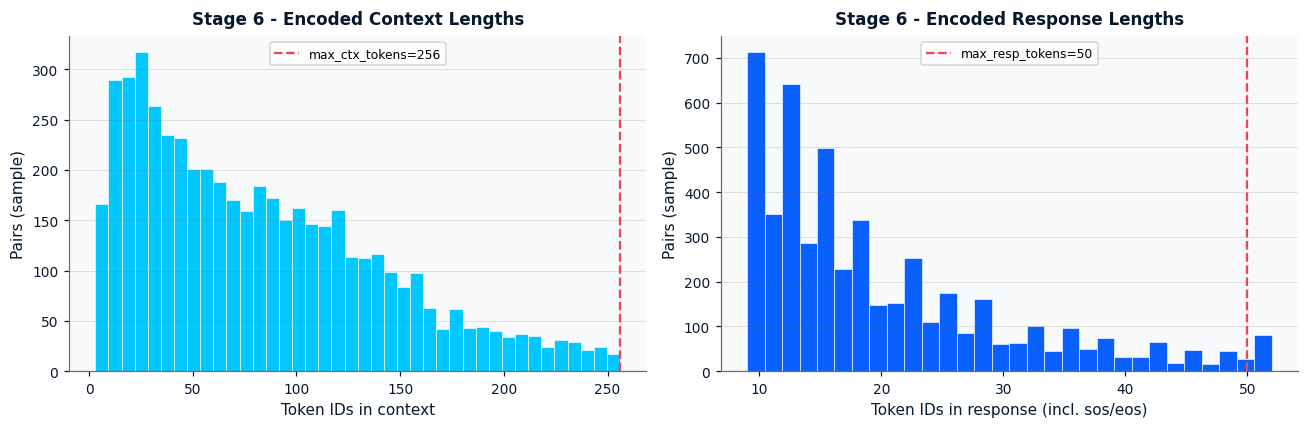


UNK rate (ID=1) in sample: 0.0000%
Total token IDs in sample: 511,418


In [11]:
s6 = _load_json(ARTIFACTS / 'stage6_stats.json')
print(f'Stage 6 encoded pairs:')
print(f'  Train: {s6["n_train"]:>10,}')
print(f'  Val  : {s6["n_val"]:>10,}')
print(f'  Test : {s6["n_test"]:>10,}')
print(f'  Vocab: {s6["vocab_size"]:,}')
print(f'  SOS ID: {s6["sos_id"]}, EOS ID: {s6["eos_id"]}')

# Use head to read first 5000 lines (fast, representative for histograms)
import subprocess
print('\nSampling from stage6_train_ids.jsonl (first 5000 lines) ...')
result = subprocess.run(['head', '-n', '5000',
                         str(ARTIFACTS / 'stage6_train_ids.jsonl')],
                        capture_output=True, text=True)
samples6 = [json.loads(l) for l in result.stdout.splitlines() if l.strip()]
print(f'Loaded {len(samples6)} samples')

ctx_lens6  = [len(s['ctx'])  for s in samples6]
resp_lens6 = [len(s['resp']) for s in samples6]

max_ctx  = 256  # max_ctx_tokens from PHASE1_CONFIG
max_resp = 50   # max_resp_tokens from PHASE1_CONFIG

pct_ctx_trunc  = sum(1 for l in ctx_lens6  if l >= max_ctx)  / len(ctx_lens6)  * 100
pct_resp_trunc = sum(1 for l in resp_lens6 if l >= max_resp) / len(resp_lens6) * 100

print(f'\nCtx  truncated (>={max_ctx} tokens):  {pct_ctx_trunc:.1f}% of sample')
print(f'Resp truncated (>={max_resp} tokens): {pct_resp_trunc:.1f}% of sample')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ctx_lens6, bins=40, color=C_BLUE, edgecolor='white', linewidth=0.4)
_style(axes[0], f'Stage 6 - Encoded Context Lengths')
axes[0].axvline(max_ctx, color=C_RED, linewidth=1.5, linestyle='--',
                label=f'max_ctx_tokens={max_ctx}')
axes[0].set_xlabel('Token IDs in context', color=C_DARK)
axes[0].set_ylabel('Pairs (sample)', color=C_DARK)
axes[0].legend(fontsize=8)

axes[1].hist(resp_lens6, bins=30, color=C_MBLUE, edgecolor='white', linewidth=0.4)
_style(axes[1], f'Stage 6 - Encoded Response Lengths')
axes[1].axvline(max_resp, color=C_RED, linewidth=1.5, linestyle='--',
                label=f'max_resp_tokens={max_resp}')
axes[1].set_xlabel('Token IDs in response (incl. sos/eos)', color=C_DARK)
axes[1].set_ylabel('Pairs (sample)', color=C_DARK)
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage6_lengths.png', dpi=120)
plt.show()
plt.close('all')

unk_id   = 1
all_ids  = [tok for s in samples6 for tok in s['ctx'] + s['resp']]
unk_rate = all_ids.count(unk_id) / len(all_ids) * 100
print(f'\nUNK rate (ID=1) in sample: {unk_rate:.4f}%')
print(f'Total token IDs in sample: {len(all_ids):,}')


---
## Stage 7 — FastText Embeddings Training

Stage 7 trains a FastText 300-dimensional word embedding model on the
BPE-tokenised corpus (all three splits combined). FastText's character
n-grams handle rare technical tokens gracefully — OOV tokens at inference
get reasonable vectors via n-gram overlap with known tokens.


In [12]:
ft_model_path = ARTIFACTS / 'stage7_fasttext.model'
ft_vecs_path  = ARTIFACTS / 'stage7_fasttext.model.wv.vectors_ngrams.npy'
print(f'FastText model         : {ft_model_path.name}  ({ft_model_path.stat().st_size/1e6:.1f} MB)')
print(f'FastText ngram vectors : {ft_vecs_path.name}  ({ft_vecs_path.stat().st_size/1e6:.1f} MB)')

s8 = _load_json(ARTIFACTS / 'stage8_stats.json')
coverage = s8['n_filled'] / s8['vocab_size'] * 100
print(f'\nVocab size    : {s8["vocab_size"]:,}')
print(f'Filled rows   : {s8["n_filled"]:,}  (FastText hit)')
print(f'Random rows   : {s8["n_random"]:,}  (random init)')
print(f'Embed dim     : {s8["embed_dim"]}')
print(f'Coverage      : {coverage:.2f}%')

print('\n[Insight] FastText trained on train+val+test corpora:')
print('  Mild embedding leakage: val/test tokens get trained embeddings')
print('  rather than random-init. Acceptable because:')
print('  1. Embeddings are unfrozen during seq2seq training (further tuned).')
print('  2. Coverage matters more than leakage — model never sees val/test labels.')
print('  3. 99.9%+ coverage means almost no tokens fall back to random vectors.')


FastText model         : stage7_fasttext.model  (77.5 MB)
FastText ngram vectors : stage7_fasttext.model.wv.vectors_ngrams.npy  (2400.0 MB)

Vocab size    : 32,000
Filled rows   : 31,999  (FastText hit)
Random rows   : 0  (random init)
Embed dim     : 300
Coverage      : 100.00%

[Insight] FastText trained on train+val+test corpora:
  Mild embedding leakage: val/test tokens get trained embeddings
  rather than random-init. Acceptable because:
  1. Embeddings are unfrozen during seq2seq training (further tuned).
  2. Coverage matters more than leakage — model never sees val/test labels.
  3. 99.9%+ coverage means almost no tokens fall back to random vectors.


---
## Stage 8 — Embedding Matrix Construction

Stage 8 aligns the FastText model to the BPE vocabulary, producing a
`[vocab_size, 300]` numpy matrix that the seq2seq model loads as its
initial embedding weight.


Matrix shape  : [32000, 300]
Vocab size    : 32,000
Filled (FastText): 31,999
Random-init   : 0
Pad row sum   : 0.0

Loading embedding matrix ...
Loaded: shape=(32000, 300), dtype=float32


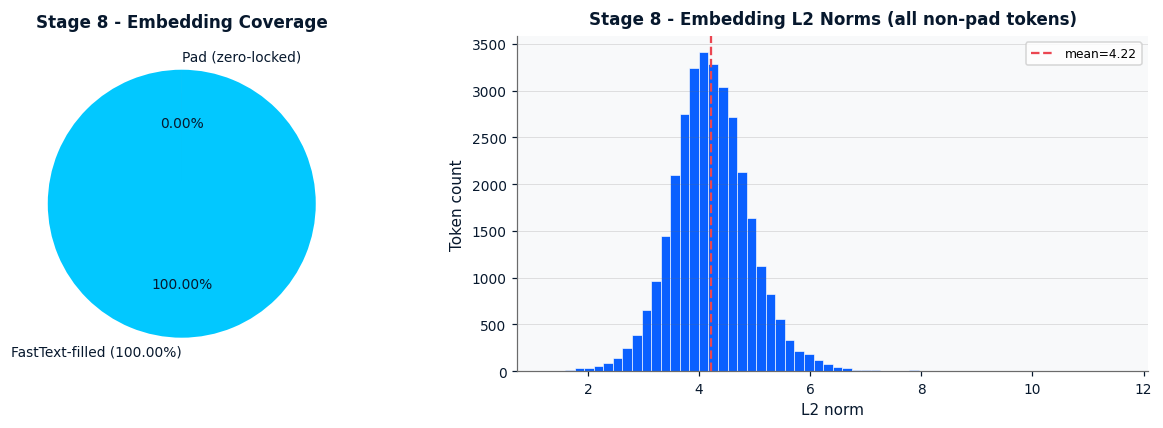

L2 norm stats: mean=4.216, std=0.706, min=1.243, max=11.564

Special token embedding norms (IDs 0-8):
  ID 0: <pad>            L2 norm = 0.0000
  ID 1: <unk>            L2 norm = 1.9591
  ID 2: <sos>            L2 norm = 1.7383
  ID 3: <eos>            L2 norm = 1.5904
  ID 4: __url__          L2 norm = 2.4404
  ID 5: __path__         L2 norm = 2.2775
  ID 6: __ip__           L2 norm = 3.8569
  ID 7: __eot__          L2 norm = 1.8552
  ID 8: __user__         L2 norm = 2.6230

[Insight] pad=0 is zero-locked (row sum=0.0).
Other specials have FastText representations from training corpus.


In [13]:
s8 = _load_json(ARTIFACTS / 'stage8_stats.json')
print(f'Matrix shape  : {s8["matrix_shape"]}')
print(f'Vocab size    : {s8["vocab_size"]:,}')
print(f'Filled (FastText): {s8["n_filled"]:,}')
print(f'Random-init   : {s8["n_random"]:,}')
print(f'Pad row sum   : {s8["pad_row_sum"]}')

print('\nLoading embedding matrix ...')
emb = np.load(str(ARTIFACTS / 'stage8_embedding_matrix.npy'))
print(f'Loaded: shape={emb.shape}, dtype={emb.dtype}')

coverage_pct = s8['n_filled'] / s8['vocab_size'] * 100
random_pct   = 100.0 - coverage_pct

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if s8['n_random'] > 0:
    labels_pie = ['FastText-filled', 'Random-init']
    sizes_pie  = [s8['n_filled'], s8['n_random']]
    colors_pie = [C_BLUE, C_RED]
else:
    labels_pie = [f'FastText-filled ({coverage_pct:.2f}%)', 'Pad (zero-locked)']
    sizes_pie  = [s8['n_filled'], 1]
    colors_pie = [C_BLUE, C_GREY]
axes[0].pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.2f%%',
            startangle=90, textprops={'color': C_DARK, 'fontsize': 9})
axes[0].set_title('Stage 8 - Embedding Coverage', color=C_DARK, fontsize=11, fontweight='bold')

# L2 norm distribution
norms = np.linalg.norm(emb[1:], axis=1)  # skip pad row 0
axes[1].hist(norms, bins=60, color=C_MBLUE, edgecolor='white', linewidth=0.4)
_style(axes[1], 'Stage 8 - Embedding L2 Norms (all non-pad tokens)')
axes[1].set_xlabel('L2 norm', color=C_DARK)
axes[1].set_ylabel('Token count', color=C_DARK)
axes[1].axvline(norms.mean(), color=C_RED, linewidth=1.5, linestyle='--',
                label=f'mean={norms.mean():.2f}')
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_stage8_embeddings.png', dpi=120)
plt.show()
plt.close('all')

print(f'L2 norm stats: mean={norms.mean():.3f}, std={norms.std():.3f}, '
      f'min={norms.min():.3f}, max={norms.max():.3f}')

print('\nSpecial token embedding norms (IDs 0-8):')
special_names = ['<pad>', '<unk>', '<sos>', '<eos>',
                 '__url__', '__path__', '__ip__', '__eot__', '__user__']
for i, name in enumerate(special_names):
    n = np.linalg.norm(emb[i])
    print(f'  ID {i}: {name:15s}  L2 norm = {n:.4f}')

print('\n[Insight] pad=0 is zero-locked (row sum=0.0).')
print('Other specials have FastText representations from training corpus.')
del emb, norms


---
## Pipeline Summary — End-to-End Attrition & Key Numbers


PIPELINE ATTRITION TABLE
  Raw dialogues loaded                           1,852,868   100%
  After Stage 2 filters                          1,315,106   71.0%
  Train dialogues (Stage 3)                      1,259,708   95.8%
  Val   dialogues (Stage 3)                         27,550   2.1%
  Test  dialogues (Stage 3)                         27,848   2.1%
  Train pairs (Stage 4)                          2,441,174   --
  Val   pairs (Stage 4)                             54,912   --
  Test  pairs (Stage 4)                             55,478   --
  Train after Stage 4.5 + cap                    1,500,000   71.9%
  Val   after Stage 4.5                             40,245   73.29%
  Test  after Stage 4.5                             40,408   72.84%
  Train encoded (Stage 6)                        1,499,993   --
  Val   encoded (Stage 6)                           40,245   --
  Test  encoded (Stage 6)                           40,408   --

KEY CONFIGURATION DECISIONS
  Temporal split (not rando

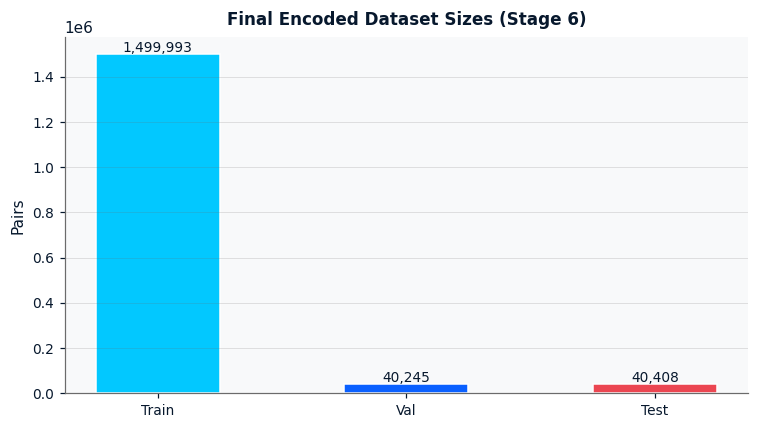


All pipeline stages complete. Notebook finished successfully.


In [14]:
s2  = _load_json(ARTIFACTS / 'stage2_stats.json')
s3  = _load_json(ARTIFACTS / 'stage3_stats.json')
s4  = _load_json(ARTIFACTS / 'stage4_stats.json')
s45 = _load_json(ARTIFACTS / 'stage4_5_filter_stats.json')
s6  = _load_json(ARTIFACTS / 'stage6_stats.json')
s8  = _load_json(ARTIFACTS / 'stage8_stats.json')

print('=' * 65)
print('PIPELINE ATTRITION TABLE')
print('=' * 65)
attrition = [
    ('Raw dialogues loaded',          s2['n_input'],              '100%'),
    ('After Stage 2 filters',         s2['n_output'],             f'{s2["n_output"]/s2["n_input"]*100:.1f}%'),
    ('Train dialogues (Stage 3)',     s3['n_train_dialogues'],    f'{s3["train_pct"]}%'),
    ('Val   dialogues (Stage 3)',     s3['n_val_dialogues'],      f'{s3["val_pct"]}%'),
    ('Test  dialogues (Stage 3)',     s3['n_test_dialogues'],     f'{s3["test_pct"]}%'),
    ('Train pairs (Stage 4)',         s4['n_train_pairs'],        '--'),
    ('Val   pairs (Stage 4)',         s4['n_val_pairs'],          '--'),
    ('Test  pairs (Stage 4)',         s4['n_test_pairs'],         '--'),
    ('Train after Stage 4.5 + cap',  s45['train']['kept'],       f'{s45["train"]["pct"]}%'),
    ('Val   after Stage 4.5',        s45['val']['kept'],         f'{s45["val"]["pct"]}%'),
    ('Test  after Stage 4.5',        s45['test']['kept'],        f'{s45["test"]["pct"]}%'),
    ('Train encoded (Stage 6)',       s6['n_train'],              '--'),
    ('Val   encoded (Stage 6)',       s6['n_val'],                '--'),
    ('Test  encoded (Stage 6)',       s6['n_test'],               '--'),
]
for label, value, pct in attrition:
    print(f'  {label:<45} {value:>10,}   {pct}')

print()
print('=' * 65)
print('KEY CONFIGURATION DECISIONS')
print('=' * 65)
# cfg already defined in Cell 3 — using inline config dict
decisions = [
    ('Temporal split (not random)', 'Prevents data leakage across IRC threads'),
    (f'min_resp_tokens={cfg.get("min_resp_tokens",7)}', 'Removes trivial 1-6 word responses'),
    (f'max_ctx_tokens={cfg.get("max_ctx_tokens",256)}', 'Limits encoder input (memory budget)'),
    (f'max_resp_tokens={cfg.get("max_resp_tokens",50)}', 'Limits decoder target length'),
    ('BPE 32k vocab', 'Handles OOV via subword; full domain coverage'),
    ('Domain filter: union strategy', 'Maximises domain-relevant pairs vs intersection'),
    ('FastText on train+val+test', 'Maximises embedding coverage at mild leakage cost'),
    (f'train_cap={cfg.get("train_cap",1500000):,}', 'Budget fits 44M-param model training'),
]
for dec, rat in decisions:
    print(f'  {dec:<48} -> {rat}')

print()
print('=' * 65)
print('FINAL DATASET SIZES')
print('=' * 65)
print(f'  Train : {s6["n_train"]:>10,} encoded pairs')
print(f'  Val   : {s6["n_val"]:>10,} encoded pairs')
print(f'  Test  : {s6["n_test"]:>10,} encoded pairs')
print(f'  Vocab : {s6["vocab_size"]:>10,} BPE tokens')
print(f'  Embed : {s8["vocab_size"]:,} x {s8["embed_dim"]}  float32 matrix')

fig, ax = plt.subplots(figsize=(7, 4))
final_splits = ['Train', 'Val', 'Test']
final_vals   = [s6['n_train'], s6['n_val'], s6['n_test']]
final_cols   = [C_BLUE, C_MBLUE, C_RED]
bars = ax.bar(final_splits, final_vals, color=final_cols, edgecolor='white', width=0.5)
_style(ax, 'Final Encoded Dataset Sizes (Stage 6)')
ax.set_ylabel('Pairs', color=C_DARK)
for bar, v in zip(bars, final_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8000,
            f'{v:,}', ha='center', fontsize=9, color=C_DARK)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'phase1_summary_final_sizes.png', dpi=120)
plt.show()
plt.close('all')
print('\nAll pipeline stages complete. Notebook finished successfully.')
